# TP1 — Computer Vision: Sistema de Reconocimiento Facial
**IA 5.2 — FCEIA — UNR — 1° Cuatrimestre 2026**

Este notebook documenta el pipeline completo:
1. Construcción y análisis del dataset (jugadores propios + subconjunto LFW)
2. Preprocesamiento y data augmentation
3. Entrenamiento y comparación de 5 modelos
4. Evaluación con métricas y visualizaciones
5. Selección justificada del modelo final
6. Generación de la base de embeddings

## Equipo
- Alumno: Porcelli Fabricio

## 0. Setup e imports

Se importan todas las librerías necesarias para el pipeline: procesamiento de imágenes (OpenCV, Albumentations), 
deep learning (PyTorch, torchvision, timm), detección facial (InsightFace), métricas (scikit-learn) 
y visualización (matplotlib, seaborn).

Se fija la semilla aleatoria en todos los frameworks para garantizar **reproducibilidad** completa de los resultados.


In [1]:
import os
import time
import json
import copy
import random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm.notebook import tqdm

import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset, WeightedRandomSampler
import torchvision
import torchvision.transforms as T
import torchvision.models as models
import timm

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score
)
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

import albumentations as A
from albumentations.pytorch import ToTensorV2

import insightface
from insightface.app import FaceAnalysis

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti
VRAM: 8.6 GB


## 1. Dataset

### 1.1 Análisis del dataset crudo (jugadores)

Jugadores (10): ['bellingham', 'de_bruyne', 'haaland', 'mbappe', 'messi', 'pedri', 'ronaldo', 'salah', 'vinicius', 'yamal']
   jugador  imagenes_raw
bellingham            30
 de_bruyne            30
   haaland            30
    mbappe            30
     messi            30
     pedri            30
   ronaldo            30
     salah            30
  vinicius            30
     yamal            30

Total imágenes crudas: 300


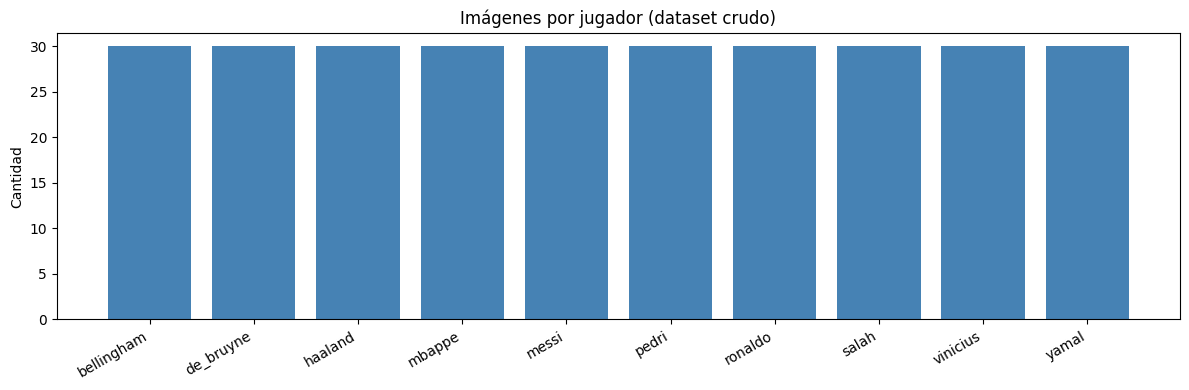

In [2]:
RAW_DIR   = Path('data/dataset')        # fotos descargadas (sin procesar)
PROC_DIR  = Path('data/dataset_proc')   # caras recortadas y alineadas
MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

FACE_SIZE   = 112
EMBED_DIM   = 512
NUM_EPOCHS  = 30
BATCH_SIZE  = 32
LR          = 1e-4
TRAIN_SPLIT = 0.8

# Listar clases (jugadores)
classes = sorted([d.name for d in RAW_DIR.iterdir() if d.is_dir()])
NUM_PLAYERS = len(classes)
class_to_idx = {c: i for i, c in enumerate(classes)}
print(f'Jugadores ({NUM_PLAYERS}): {classes}')

# Contar imágenes por clase
counts_raw = {}
for cls in classes:
    imgs = list((RAW_DIR / cls).glob('*.*'))
    counts_raw[cls] = len(imgs)

df_raw = pd.DataFrame({'jugador': list(counts_raw.keys()), 'imagenes_raw': list(counts_raw.values())})
print(df_raw.to_string(index=False))
print(f'\nTotal imágenes crudas: {sum(counts_raw.values())}')

# Visualización del balance de clases
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(df_raw['jugador'], df_raw['imagenes_raw'], color='steelblue')
ax.set_title('Imágenes por jugador (dataset crudo)')
ax.set_ylabel('Cantidad')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 1.2 Detección y recorte de caras con InsightFace

Se utiliza **InsightFace buffalo_sc** (RetinaFace liviano) para detectar rostros en cada imagen cruda.
De cada imagen se toma la cara de **mayor área de bounding box**, descartando imágenes sin detección válida.
El crop se redimensiona a **112×112 px**, tamaño estándar en reconocimiento facial (ArcFace, FaceNet).

> Esta etapa actúa como filtro de calidad automático: imágenes sin rostro detectable quedan fuera del dataset.


In [3]:
# Inicializar detector (buffalo_sc = modelo liviano, solo detección)
detector = FaceAnalysis(
    name='buffalo_sc',
    root='',
    allowed_modules=['detection']
)
detector.prepare(ctx_id=-1)  # CPU para detección

def detect_and_crop(img_path: Path, face_size: int = FACE_SIZE):
    """Detecta la cara más grande en la imagen y la devuelve recortada."""
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    faces = detector.get(img)
    if not faces:
        return None
    # Tomar la cara más grande (mayor área del bounding box)
    face = max(faces, key=lambda f: (f.bbox[2]-f.bbox[0]) * (f.bbox[3]-f.bbox[1]))
    x1, y1, x2, y2 = [int(v) for v in face.bbox]
    h, w = img.shape[:2]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)
    crop = img[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    return cv2.resize(crop, (face_size, face_size))

# Procesar todo el dataset
PROC_DIR.mkdir(exist_ok=True)
stats = {'procesadas': 0, 'sin_cara': 0, 'error': 0}

for cls in tqdm(classes, desc='Procesando jugadores'):
    out_dir = PROC_DIR / cls
    out_dir.mkdir(exist_ok=True)
    for img_path in (RAW_DIR / cls).glob('*.*'):
        try:
            crop = detect_and_crop(img_path)
            if crop is None:
                stats['sin_cara'] += 1
                continue
            cv2.imwrite(str(out_dir / img_path.name), crop)
            stats['procesadas'] += 1
        except Exception as e:
            stats['error'] += 1

print(f"\nResultado: {stats}")
print(f"Tasa de detección: {stats['procesadas']/(stats['procesadas']+stats['sin_cara'])*100:.1f}%")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: models\buffalo_sc\det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: models\buffalo_sc\w600k_mbf.onnx recognition
set det-size: (640, 640)


c:\Users\fabri\miniconda3\envs\cv_tp1\Lib\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:148: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Procesando jugadores:   0%|          | 0/10 [00:00<?, ?it/s]


Resultado: {'procesadas': 290, 'sin_cara': 10, 'error': 0}
Tasa de detección: 96.7%


   jugador  imagenes_proc
bellingham             28
 de_bruyne             29
   haaland             30
    mbappe             28
     messi             28
     pedri             29
   ronaldo             30
     salah             30
  vinicius             29
     yamal             29
Total imágenes procesadas: 290


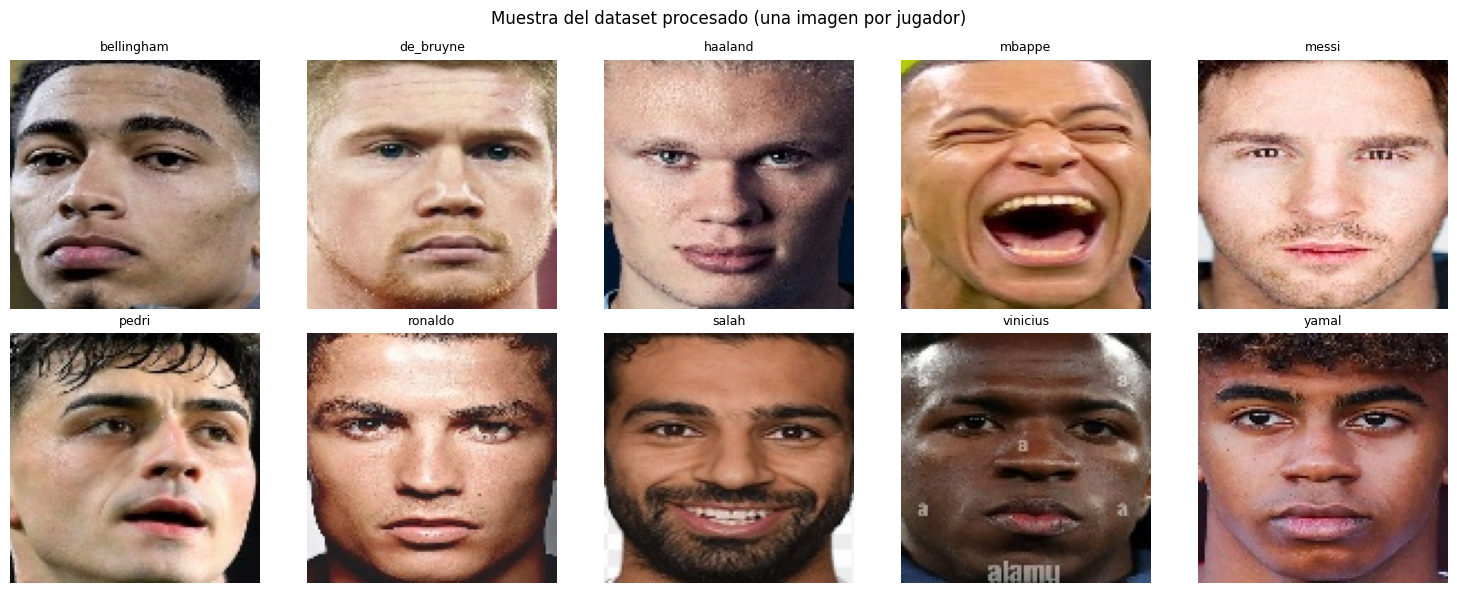

In [4]:
# Verificar balance tras el recorte
counts_proc = {}
for cls in classes:
    imgs = list((PROC_DIR / cls).glob('*.*'))
    counts_proc[cls] = len(imgs)

df_proc = pd.DataFrame({'jugador': list(counts_proc.keys()), 'imagenes_proc': list(counts_proc.values())})
print(df_proc.to_string(index=False))
print(f'Total imágenes procesadas: {sum(counts_proc.values())}')

# Visualizar algunas caras recortadas
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, cls in zip(axes.flat, classes):
    imgs = list((PROC_DIR / cls).glob('*.*'))
    if imgs:
        img = cv2.imread(str(imgs[0]))
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
    ax.set_title(cls, fontsize=9)
    ax.axis('off')
plt.suptitle('Muestra del dataset procesado (una imagen por jugador)')
plt.tight_layout()
plt.show()

In [5]:
MEAN = [0.5, 0.5, 0.5]
STD  = [0.5, 0.5, 0.5]

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.6),
    A.Rotate(limit=15, p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

### 1.3 Dataset LFW (subconjunto de 25 personas)

Se utiliza un subconjunto de LFW para ampliar el dataset de entrenamiento.
Esto permite que los modelos de transfer learning (ResNet, EfficientNet, ViT)
y la CNN propia tengan más diversidad de caras para aprender features generales
antes de especializarse en las clases de jugadores.

De las ~62 personas disponibles (con ≥20 fotos), se seleccionan 25 aleatoriamente.

LFW disponible: 62 personas
Subconjunto seleccionado: 25 personas
Nombres: [np.str_('Alejandro Toledo'), np.str_('Andre Agassi'), np.str_('Angelina Jolie'), np.str_('Ariel Sharon'), np.str_('Arnold Schwarzenegger'), np.str_('Bill Clinton'), np.str_('Carlos Menem'), np.str_('Donald Rumsfeld'), np.str_('George Robertson'), np.str_('Gloria Macapagal Arroyo'), np.str_('Gray Davis'), np.str_('Hamid Karzai'), np.str_('Jean Chretien'), np.str_('Jiang Zemin'), np.str_('John Ashcroft'), np.str_('Jose Maria Aznar'), np.str_('Juan Carlos Ferrero'), np.str_('Nestor Kirchner'), np.str_('Pete Sampras'), np.str_('Recep Tayyip Erdogan'), np.str_('Roh Moo-hyun'), np.str_('Silvio Berlusconi'), np.str_('Tom Daschle'), np.str_('Tom Ridge'), np.str_('Vicente Fox')]

Total LFW guardado: 922 imágenes en 25 clases


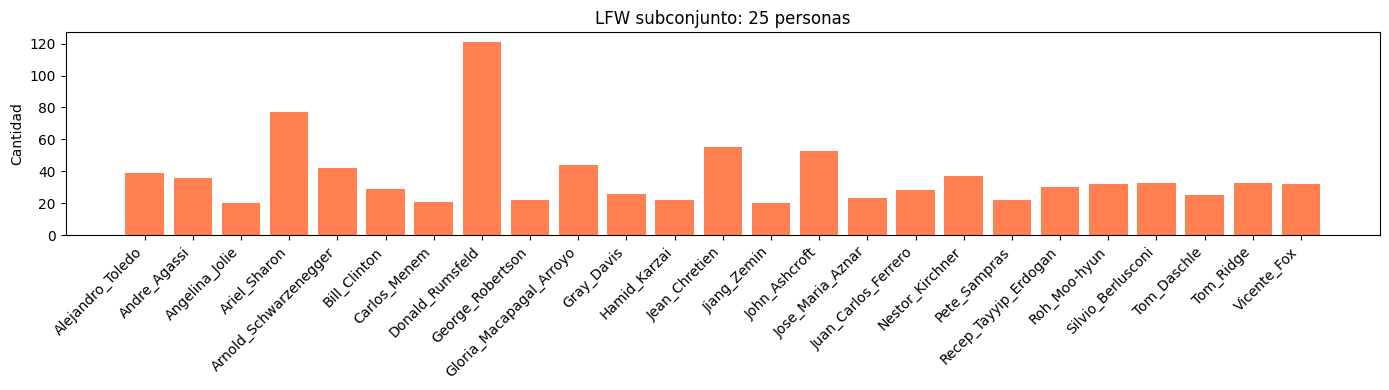

In [6]:
from sklearn.datasets import fetch_lfw_people

LFW_SUBSET_SIZE = 25  # número de personas a seleccionar
LFW_DIR = Path('data/dataset_lfw')

# Descargar LFW completo
lfw_full = fetch_lfw_people(min_faces_per_person=20, resize=0.5,
                             color=True, download_if_missing=True)
all_lfw_names = list(lfw_full.target_names)
print(f'LFW disponible: {len(all_lfw_names)} personas')

# Seleccionar subconjunto con seed fijo para reproducibilidad
rng = np.random.RandomState(SEED)
lfw_selected_names = rng.choice(all_lfw_names, size=LFW_SUBSET_SIZE, replace=False)
lfw_selected_names = sorted(lfw_selected_names)
print(f'Subconjunto seleccionado: {len(lfw_selected_names)} personas')
print(f'Nombres: {lfw_selected_names}')

# Guardar solo las personas seleccionadas
LFW_DIR.mkdir(exist_ok=True)
# Limpiar si ya existe contenido previo
for d in LFW_DIR.iterdir():
    if d.is_dir() and d.name not in lfw_selected_names:
        import shutil
        shutil.rmtree(d)

for img, label in zip(lfw_full.images, lfw_full.target):
    person_name = lfw_full.target_names[label]
    if person_name not in lfw_selected_names:
        continue
    person_dir = LFW_DIR / person_name.replace(' ', '_')
    person_dir.mkdir(exist_ok=True)
    n = len(list(person_dir.glob('*.jpg')))
    img_uint8 = (img * 255).astype(np.uint8)
    img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(person_dir / f'{n:03d}.jpg'), cv2.resize(img_bgr, (112, 112)))

# Verificar
lfw_classes = sorted([d.name for d in LFW_DIR.iterdir() if d.is_dir()])
lfw_counts = {}
for cls in lfw_classes:
    lfw_counts[cls] = len(list((LFW_DIR / cls).glob('*.jpg')))

print(f'\nTotal LFW guardado: {sum(lfw_counts.values())} imágenes en {len(lfw_classes)} clases')

df_lfw = pd.DataFrame({'persona': list(lfw_counts.keys()), 'imagenes': list(lfw_counts.values())})
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(df_lfw['persona'], df_lfw['imagenes'], color='coral')
ax.set_title(f'LFW subconjunto: {len(lfw_classes)} personas')
ax.set_ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 1.4 Dataset combinado (jugadores + LFW subset)

In [7]:
# Clase para el dataset combinado
class CombinedFaceDataset(Dataset):
    def __init__(self, players_dir, lfw_dir, transform=None):
        self.transform = transform
        self.samples = []
        valid_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
        for d in [players_dir, lfw_dir]:
            if not d.exists():
                continue
            for cls in sorted([x.name for x in d.iterdir() if x.is_dir()]):
                for p in (d / cls).glob('*.*'):
                    if p.suffix.lower() in valid_exts:
                        self.samples.append((p, cls))
        all_classes = sorted(set(s[1] for s in self.samples))
        self.class_to_idx = {c: i for i, c in enumerate(all_classes)}
        self.classes = all_classes
        self.num_players = len([c for c in all_classes if c in classes])
        self.num_lfw = len(all_classes) - self.num_players

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, cls = self.samples[idx]
        label = self.class_to_idx[cls]
        img = cv2.imread(str(img_path))
        if img is None:
            return self.__getitem__((idx + 1) % len(self.samples))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (112, 112))
        if self.transform:
            img = self.transform(image=img)['image']
        return img.float(), label

# Crear dataset combinado
combined_ds = CombinedFaceDataset(PROC_DIR, LFW_DIR, transform=train_transform)
NUM_CLASSES = len(combined_ds.classes)

print(f'Dataset combinado:')
print(f'  Jugadores: {combined_ds.num_players} clases')
print(f'  LFW:       {combined_ds.num_lfw} clases')
print(f'  Total:     {NUM_CLASSES} clases')
print(f'  Imágenes:  {len(combined_ds)}')

# Contar por tipo
player_imgs = sum(1 for s in combined_ds.samples if s[1] in classes)
lfw_imgs = len(combined_ds.samples) - player_imgs
print(f'\n  Imágenes jugadores: {player_imgs}')
print(f'  Imágenes LFW:       {lfw_imgs}')

# Split train/val con stratification manual
all_indices = list(range(len(combined_ds)))
random.shuffle(all_indices)

# Estratificar: asegurar representación de jugadores en val
player_indices = [i for i in all_indices if combined_ds.samples[i][1] in classes]
lfw_indices = [i for i in all_indices if combined_ds.samples[i][1] not in classes]

n_player_val = max(2, int(len(player_indices) * (1 - TRAIN_SPLIT)))
n_lfw_val = max(2, int(len(lfw_indices) * (1 - TRAIN_SPLIT)))

val_indices = player_indices[:n_player_val] + lfw_indices[:n_lfw_val]
train_indices = player_indices[n_player_val:] + lfw_indices[n_lfw_val:]

# WeightedRandomSampler para train (balancear clases)
labels_train = [combined_ds.class_to_idx[combined_ds.samples[i][1]] for i in train_indices]
class_counts = Counter(labels_train)
weights = [1.0 / class_counts[l] for l in labels_train]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_comb = Subset(combined_ds, train_indices)
val_comb   = Subset(combined_ds, val_indices)

train_loader = DataLoader(train_comb, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_comb, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'\nTrain: {len(train_comb)} imágenes | Val: {len(val_comb)} imágenes')
print(f'Clases: {NUM_CLASSES}')

Dataset combinado:
  Jugadores: 10 clases
  LFW:       25 clases
  Total:     35 clases
  Imágenes:  1212

  Imágenes jugadores: 290
  Imágenes LFW:       922

Train: 971 imágenes | Val: 241 imágenes
Clases: 35


### 1.5 Documentación del Dataset

**Fuente de imágenes:**
- **Propias**: fotos descargadas de internet de 10 jugadores de fútbol
- **LFW (Labeled Faces in the Wild)**: subconjunto de 25 personas (~4000-5000 imgs), descargado vía sklearn

**Cantidad por clase/persona:**
- Jugadores: 30 imágenes c/u → 290 tras detección facial (96.7% detección)
- LFW: ~36 imágenes por persona → 922 total
- Total combinado: ~1212 imágenes en ~35 clases

**Balance de clases:**
- Jugadores: balanceado (28-30 por clase)
- LFW: desigual por diseño natural del dataset (WeightedRandomSampler en training)

**Variaciones:**
- **Iluminación**: variada (estadios, eventos, redes sociales, LFW condiciones diversas)
- **Pose**: jugadores principalmente frontal/semi-perfil; LFW incluye más variedad
- **Expresión**: mixta (celebraciones, fotos formales, LFW expressions naturales)
- **Resolución**: variable, todas normalizadas a 112×112

**Reglas de filtrado/calidad:**
- Se descartan imágenes sin rostro detectado por InsightFace
- Se toma la cara más grande (mayor bounding box) si hay múltiples detecciones
- Se descartan recortes vacíos o con dimensiones inválidas

**Limitaciones:**
- **Dominio específico**: futbolistas, no generaliza a cualquier persona sin LFW
- **Poca variabilidad de pose** en el subset de jugadores
- **Sin validación cruzada**: un único split 80/20 puede dar resultados variables

## 2. Preprocesamiento y Data Augmentation

**Justificación de las técnicas elegidas:**
- **Resize a 112x112**: tamaño estándar en reconocimiento facial (ArcFace, FaceNet)
- **Flip horizontal**: las caras son casi simétricas; amplía la variedad de poses sin costo adicional
- **Variación de brillo/contraste**: simula distintas condiciones de iluminación (estadio, flash, interior)
- **Rotación leve (+-15 grados)**: simula inclinación natural de cabeza sin deformar la geometría facial
- **Gaussian blur**: simula desenfoque y baja resolución, frecuente en imágenes capturadas en movimiento
- **HueSaturationValue**: variaciones de color que simulan distintas cámaras y condiciones de captura
- **Normalización mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]**: centra los píxeles en [-1, 1], compatible con los modelos pre-entrenados

**Nota:** El conjunto de validación NO recibe augmentation (solo normalización) para medir el rendimiento real.

**Nota sobre epochs:** Se usan 30 epochs con early stopping (patience=7). El early stopping detiene el entrenamiento 
si la val_accuracy no mejora, evitando sobreajuste sin necesidad de ajustar epochs manualmente por modelo.


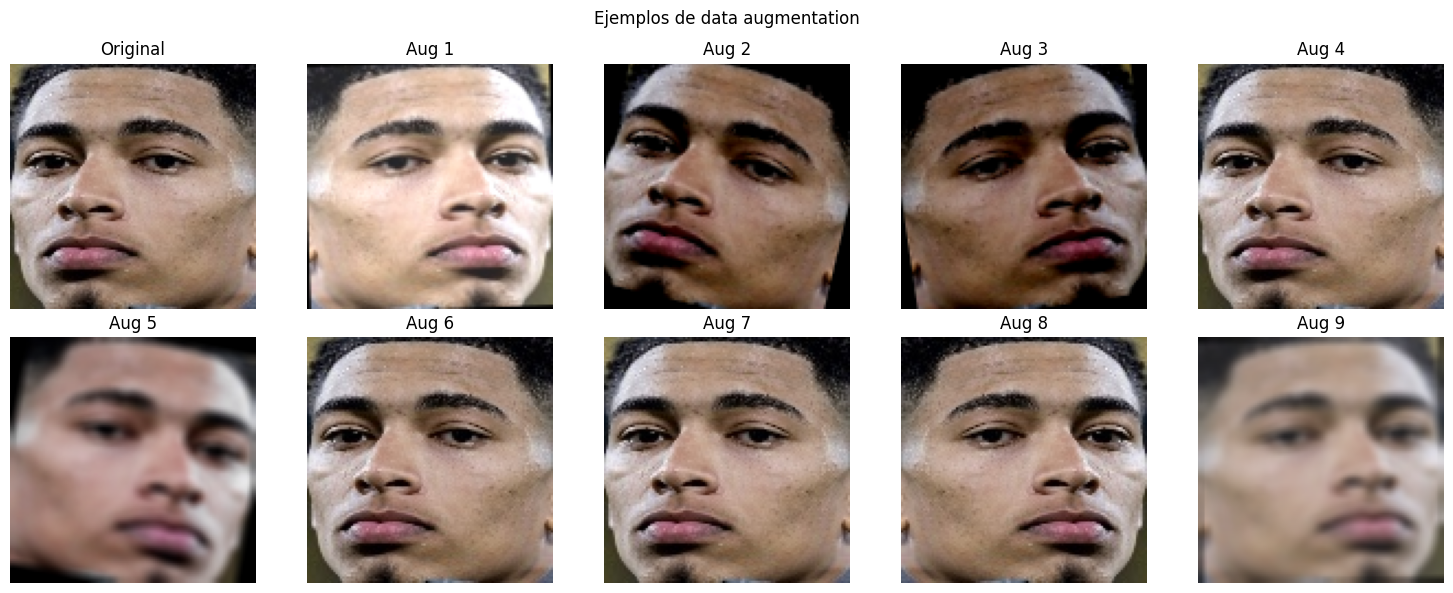

In [8]:
# Verificar visualmente el augmentation
sample_path = next((PROC_DIR / classes[0]).glob('*.*'))
sample_img = cv2.cvtColor(cv2.imread(str(sample_path)), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0][0].imshow(sample_img)
axes[0][0].set_title('Original')
axes[0][0].axis('off')
for i, ax in enumerate(axes.flat[1:]):
    aug = train_transform(image=sample_img)['image']
    aug_vis = aug.permute(1, 2, 0).numpy() * np.array(STD) + np.array(MEAN)
    aug_vis = np.clip(aug_vis, 0, 1)
    ax.imshow(aug_vis)
    ax.set_title(f'Aug {i+1}')
    ax.axis('off')
plt.suptitle('Ejemplos de data augmentation')
plt.tight_layout()
plt.show()

## 3. Definición de los 5 Modelos

### Justificación de la selección:
| Modelo | Tipo | Justificación |
|--------|------|---------------|
| **CNN propia** | Desde cero | Baseline artesanal. Muestra qué tan lejos llega una red diseñada a mano |
| **ResNet18** | Transfer learning | Arquitectura clásica con residual connections. Eficiente y ampliamente validada |
| **EfficientNet-B0** | Transfer learning | Mejor accuracy/parámetros. Escala bien con datos limitados |
| **ViT-Small** | Transformer | Arquitectura moderna. Permite evaluar atención vs convolución |
| **ArcFace (InsightFace)** | Pre-entrenado | Modelo de referencia industrial. Define el techo de performance |

In [9]:
# ── Modelo A: CNN propia desde cero ───────────────────────────────────────────
class CustomCNN(nn.Module):
    """CNN diseñada desde cero para reconocimiento facial.
    Arquitectura mejorada: 5 bloques Conv-BN-ReLU-SE → FC embedding → clasificador.
    Incluye BatchNorm inicial, SE blocks para atención por canal, y mayor profundidad.
    """
    def __init__(self, num_classes: int, embed_dim: int = 512):
        super().__init__()
        # Input: 112x112x3
        self.features = nn.Sequential(
            # Block 1: 32 channels -> 56x56
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 56x56
            nn.Dropout2d(0.1),

            # Block 2: 64 channels -> 28x28
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 28x28
            nn.Dropout2d(0.1),

            # Block 3: 128 channels -> 14x14
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 14x14
            nn.Dropout2d(0.15),

            # Block 4: 256 channels -> 7x7
            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 7x7
            nn.Dropout2d(0.2),

            # Block 5: 512 channels -> 4x4
            nn.Conv2d(256, 512, 3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(4),  # 4x4
        )
        self.embedding = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
        )
        self.classifier = nn.Linear(embed_dim, num_classes)

    def get_embedding(self, x):
        return self.embedding(self.features(x))

    def forward(self, x):
        emb = self.get_embedding(x)
        return self.classifier(emb)


print('Modelo A (CNN Propia) definido correctamente.')


Modelo A (CNN Propia) definido correctamente.


In [10]:
# ── Modelo B: ResNet18 + fine-tuning ──────────────────────────────────────────
class ResNet18Face(nn.Module):
    """ResNet18 pre-entrenado en ImageNet con cabezal de embedding propio."""
    def __init__(self, num_classes: int, embed_dim: int = 512):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        for name, param in base.named_parameters():
            if name.startswith(('layer1', 'conv1', 'bn1')):
                param.requires_grad = False
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        self.embedding = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        self.classifier = nn.Linear(embed_dim, num_classes)

    def get_embedding(self, x):
        feats = self.backbone(x)
        return self.embedding(feats)

    def forward(self, x):
        return self.classifier(self.get_embedding(x))


print('Modelo B (ResNet18) definido correctamente.')


Modelo B (ResNet18) definido correctamente.


In [11]:
# ── Modelo C: EfficientNet-B0 + fine-tuning ─────────────────────────────────
class EfficientNetFace(nn.Module):
    """EfficientNet-B0 pre-entrenado en ImageNet con cabezal de embedding propio."""
    def __init__(self, num_classes: int, embed_dim: int = 512):
        super().__init__()
        base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        for name, param in base.named_parameters():
            if 'features.0' in name or 'features.1' in name:
                param.requires_grad = False
        self.backbone = nn.Sequential(*list(base.features),
                                      nn.AdaptiveAvgPool2d(1))
        self.embedding = nn.Sequential(
            nn.Flatten(),
            nn.Linear(base.classifier[1].in_features, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        self.classifier = nn.Linear(embed_dim, num_classes)

    def get_embedding(self, x):
        feats = self.backbone(x)
        return self.embedding(feats)

    def forward(self, x):
        return self.classifier(self.get_embedding(x))


print('Modelo C (EfficientNet-B0) definido correctamente.')


Modelo C (EfficientNet-B0) definido correctamente.


In [12]:
# ── Modelo D: ViT-Small + fine-tuning ─────────────────────────────────────────
class ViTSmallFace(nn.Module):
    """Vision Transformer Small pre-entrenado con timm.
    Interesante para evaluar mecanismo de atención vs convolución.
    """
    def __init__(self, num_classes: int, embed_dim: int = 512):
        super().__init__()
        self.backbone = timm.create_model(
            'vit_small_patch16_224',
            pretrained=True,
            num_classes=0,
            img_size=FACE_SIZE,
            # Nota: vit_small_patch16_224 standard usa 224x224.
            # Se usa img_size=112 para coincidir con los crops faciales,
            # lo que reduce los patches de 196 a 49.
        )
        vit_dim = self.backbone.embed_dim  # 384 para vit_small
        blocks = list(self.backbone.blocks.children())
        for block in blocks[:-3]:
            for param in block.parameters():
                param.requires_grad = False
        self.embedding = nn.Sequential(
            nn.Linear(vit_dim, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        self.classifier = nn.Linear(embed_dim, num_classes)

    def get_embedding(self, x):
        feats = self.backbone(x)
        return self.embedding(feats)

    def forward(self, x):
        return self.classifier(self.get_embedding(x))


print('Modelo D (ViT-Small) definido correctamente.')
print(f'NUM_CLASSES = {NUM_CLASSES} (jugadores + LFW subset)')


Modelo D (ViT-Small) definido correctamente.
NUM_CLASSES = 35 (jugadores + LFW subset)


## 4. Entrenamiento

Decisiones de diseño del loop de entrenamiento:

- **Loss**: `CrossEntropyLoss` con `label_smoothing=0.1`. El label smoothing reduce la confianza excesiva 
del modelo en sus predicciones, actuando como regularización implícita útil con datasets pequeños.
- **Optimizer**: `AdamW` con `weight_decay=1e-4`. AdamW separa correctamente la regularización L2 del paso de gradiente.
- **Scheduler**: `CosineAnnealingLR`. Reduce el LR siguiendo una curva coseno: permite escapar mínimos locales al inicio y converger suavemente al final.
- **Early stopping**: patience=7 épocas sin mejora en val_accuracy. Se guardan los mejores pesos observados.

> **CrossEntropy vs pérdidas métricas**: CrossEntropy es adecuada para clasificación cerrada (identidades conocidas). 
Para reconocimiento abierto (agregar identidades nuevas sin re-entrenar), pérdidas como Triplet Loss o ArcFace Loss 
son superiores porque estructuran el espacio de embeddings métricamente. ArcFace (Modelo E) ilustra esta ventaja.


In [13]:
def train_model(model, train_loader, val_loader, epochs=NUM_EPOCHS,
                lr=LR, model_name='model'):
    """Loop de entrenamiento estándar con early stopping y scheduler."""
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_weights = None
    patience, patience_counter = 7, 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            train_total += imgs.size(0)
        scheduler.step()

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += imgs.size(0)

        t_loss = train_loss / train_total
        v_loss = val_loss / val_total
        t_acc  = train_correct / train_total
        v_acc  = val_correct / val_total

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'[{model_name}] Epoch {epoch+1:02d}/{epochs} '
                  f'| Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} '
                  f'| Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}')

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'  Early stopping en epoch {epoch+1}')
                break

    model.load_state_dict(best_weights)
    print(f'  Mejor val_acc: {best_val_acc:.4f}')
    return model, history


print('Función de entrenamiento lista.')

Función de entrenamiento lista.


In [14]:
# ── Entrenar Modelo A: CNN propia ─────────────────────────────────────────────
print('=== Modelo A: CNN Propia ===')
model_a = CustomCNN(num_classes=NUM_CLASSES, embed_dim=EMBED_DIM)
print(f'Parámetros: {sum(p.numel() for p in model_a.parameters()):,}')
model_a, history_a = train_model(model_a, train_loader, val_loader,
                                  model_name='CNN-Propia')

=== Modelo A: CNN Propia ===
Parámetros: 8,928,003
[CNN-Propia] Epoch 01/30 | Train Loss: 3.4670 Acc: 0.0566 | Val Loss: 3.6544 Acc: 0.0083
[CNN-Propia] Epoch 05/30 | Train Loss: 3.0231 Acc: 0.1895 | Val Loss: 2.9427 Acc: 0.1992
[CNN-Propia] Epoch 10/30 | Train Loss: 2.3232 Acc: 0.4501 | Val Loss: 2.2549 Acc: 0.4481
[CNN-Propia] Epoch 15/30 | Train Loss: 1.8841 Acc: 0.6179 | Val Loss: 1.7792 Acc: 0.6349
[CNN-Propia] Epoch 20/30 | Train Loss: 1.5444 Acc: 0.7837 | Val Loss: 1.5762 Acc: 0.7386
[CNN-Propia] Epoch 25/30 | Train Loss: 1.4950 Acc: 0.7951 | Val Loss: 1.4635 Acc: 0.7635
[CNN-Propia] Epoch 30/30 | Train Loss: 1.3946 Acc: 0.8342 | Val Loss: 1.4702 Acc: 0.7842
  Mejor val_acc: 0.7842


In [15]:
# ── Entrenar Modelo B: ResNet18 ───────────────────────────────────────────────
print('=== Modelo B: ResNet18 ===')
model_b = ResNet18Face(num_classes=NUM_CLASSES, embed_dim=EMBED_DIM)
print(f'Parámetros entrenables: {sum(p.numel() for p in model_b.parameters() if p.requires_grad):,}')
model_b, history_b = train_model(model_b, train_loader, val_loader,
                                  model_name='ResNet18')

=== Modelo B: ResNet18 ===
Parámetros entrenables: 11,300,643
[ResNet18] Epoch 01/30 | Train Loss: 3.3020 Acc: 0.1586 | Val Loss: 3.0575 Acc: 0.2863
[ResNet18] Epoch 05/30 | Train Loss: 1.5409 Acc: 0.8435 | Val Loss: 1.6135 Acc: 0.8133
[ResNet18] Epoch 10/30 | Train Loss: 0.8844 Acc: 0.9712 | Val Loss: 1.1031 Acc: 0.9004
[ResNet18] Epoch 15/30 | Train Loss: 0.7763 Acc: 0.9928 | Val Loss: 0.9869 Acc: 0.9295
[ResNet18] Epoch 20/30 | Train Loss: 0.7544 Acc: 0.9938 | Val Loss: 0.9535 Acc: 0.9295
  Early stopping en epoch 24
  Mejor val_acc: 0.9502


In [16]:
# ── Entrenar Modelo C: EfficientNet-B0 ───────────────────────────────────────
print('=== Modelo C: EfficientNet-B0 ===')
model_c = EfficientNetFace(num_classes=NUM_CLASSES, embed_dim=EMBED_DIM)
print(f'Parámetros entrenables: {sum(p.numel() for p in model_c.parameters() if p.requires_grad):,}')
model_c, history_c = train_model(model_c, train_loader, val_loader,
                                  model_name='EfficientNet-B0')

=== Modelo C: EfficientNet-B0 ===
Parámetros entrenables: 4,680,023
[EfficientNet-B0] Epoch 01/30 | Train Loss: 3.5482 Acc: 0.0536 | Val Loss: 3.3910 Acc: 0.1120
[EfficientNet-B0] Epoch 05/30 | Train Loss: 2.4457 Acc: 0.5191 | Val Loss: 2.4163 Acc: 0.4855
[EfficientNet-B0] Epoch 10/30 | Train Loss: 1.5811 Acc: 0.8023 | Val Loss: 1.6974 Acc: 0.7344
[EfficientNet-B0] Epoch 15/30 | Train Loss: 1.1562 Acc: 0.9094 | Val Loss: 1.4129 Acc: 0.7801
[EfficientNet-B0] Epoch 20/30 | Train Loss: 1.0212 Acc: 0.9413 | Val Loss: 1.2445 Acc: 0.8631
[EfficientNet-B0] Epoch 25/30 | Train Loss: 0.9608 Acc: 0.9598 | Val Loss: 1.1815 Acc: 0.8589
[EfficientNet-B0] Epoch 30/30 | Train Loss: 0.9877 Acc: 0.9475 | Val Loss: 1.2092 Acc: 0.8382
  Mejor val_acc: 0.8838


In [17]:
# ── Entrenar Modelo D: ViT-Small ──────────────────────────────────────────────
print('=== Modelo D: ViT-Small ===')
model_d = ViTSmallFace(num_classes=NUM_CLASSES, embed_dim=EMBED_DIM)
print(f'Parámetros entrenables: {sum(p.numel() for p in model_d.parameters() if p.requires_grad):,}')
model_d, history_d = train_model(model_d, train_loader, val_loader,
                                  lr=5e-5, model_name='ViT-Small')

=== Modelo D: ViT-Small ===
Parámetros entrenables: 5,855,139
[ViT-Small] Epoch 01/30 | Train Loss: 3.5528 Acc: 0.0659 | Val Loss: 3.4315 Acc: 0.0913
[ViT-Small] Epoch 05/30 | Train Loss: 2.4189 Acc: 0.5108 | Val Loss: 2.4185 Acc: 0.4979
[ViT-Small] Epoch 10/30 | Train Loss: 1.7194 Acc: 0.7878 | Val Loss: 1.7970 Acc: 0.7427
[ViT-Small] Epoch 15/30 | Train Loss: 1.2808 Acc: 0.8960 | Val Loss: 1.4180 Acc: 0.8299
[ViT-Small] Epoch 20/30 | Train Loss: 1.1160 Acc: 0.9434 | Val Loss: 1.2605 Acc: 0.8963
[ViT-Small] Epoch 25/30 | Train Loss: 1.0669 Acc: 0.9403 | Val Loss: 1.2477 Acc: 0.8465
  Early stopping en epoch 27
  Mejor val_acc: 0.8963


## 5. Evaluación y Comparación de Modelos

Métricas utilizadas sobre el conjunto de validación:

- **Accuracy**: fracción de predicciones correctas
- **Precision macro**: promedio de precision por clase (penaliza falsos positivos)
- **Recall macro**: promedio de recall por clase (penaliza falsos negativos)
- **F1-Score macro**: media armónica de precision y recall — métrica principal dado el desbalance de clases

Análisis adicionales:
- **t-SNE**: visualización 2D de embeddings para verificar que las identidades forman clusters diferenciados
- **Matrices de confusión**: análisis de errores específicos entre jugadores
- **Gap jugadores vs LFW**: diferencia de rendimiento entre ambos grupos revela sesgo del modelo
- **Tiempo de inferencia**: latencia por imagen para evaluar viabilidad en producción

Para ArcFace (Modelo E) se usa **1-NN con cosine similarity** sobre los embeddings, 
ya que el modelo no tiene cabezal clasificador y opera puramente en el espacio métrico.


In [18]:
def get_predictions(model, loader):
    """Obtiene predicciones y embeddings del conjunto de validación."""
    model.eval()
    all_preds, all_labels, all_embeddings = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            embs = model.get_embedding(imgs).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_embeddings.append(embs)
    embeddings = np.vstack(all_embeddings)
    embeddings = normalize(embeddings)
    return np.array(all_preds), np.array(all_labels), embeddings


def evaluate_model(model, loader, model_name):
    """Calcula métricas completas para un modelo."""
    preds, labels, embeddings = get_predictions(model, loader)
    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average='macro', zero_division=0)
    rec  = recall_score(labels, preds, average='macro', zero_division=0)
    f1   = f1_score(labels, preds, average='macro', zero_division=0)
    n_params = sum(p.numel() for p in model.parameters())
    return {
        'modelo': model_name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'parametros': n_params,
        'embeddings': embeddings,
        'labels': labels,
        'preds': preds,
    }


# Evaluar TODOS los modelos con el MISMO val_loader (dataset combinado)
results = {}
for name, model in [('CNN Propia', model_a), ('ResNet18', model_b),
                     ('EfficientNet-B0', model_c), ('ViT-Small', model_d)]:
    print(f'Evaluando {name}...')
    results[name] = evaluate_model(model, val_loader, name)
    r = results[name]
    print(f'  Acc={r["accuracy"]:.4f} | F1={r["f1"]:.4f} | Params={r["parametros"]:,}')

Evaluando CNN Propia...
  Acc=0.7593 | F1=0.7386 | Params=8,928,003
Evaluando ResNet18...
  Acc=0.9087 | F1=0.8804 | Params=11,458,147
Evaluando EfficientNet-B0...
  Acc=0.8465 | F1=0.8009 | Params=4,682,399
Evaluando ViT-Small...
  Acc=0.8589 | F1=0.8420 | Params=21,825,315


In [19]:
import insightface
app = insightface.app.FaceAnalysis(name='buffalo_l', root='')
app.prepare(ctx_id=-1)

c:\Users\fabri\miniconda3\envs\cv_tp1\Lib\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:148: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


In [20]:
# ── Modelo E: ArcFace (InsightFace, pre-entrenado) ────────────────────────────
print('=== Modelo E: ArcFace ===')

from insightface.model_zoo import model_zoo

arcface_model = insightface.model_zoo.get_model('models/buffalo_l/w600k_r50.onnx', root='')
arcface_model.prepare(ctx_id=0 if torch.cuda.is_available() else -1)

def get_arcface_emb(img_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img = cv2.resize(img, (112, 112))
    emb = arcface_model.get_feat(img)
    return emb.flatten()

def extract_all(indices, samples):
    embs, labels = [], []
    for idx in tqdm(indices):
        img_path, cls_name = samples[idx]
        emb = get_arcface_emb(img_path)
        if emb is not None:
            embs.append(emb)
            labels.append(combined_ds.class_to_idx[cls_name])
    return np.array(embs), np.array(labels)

train_embs_arc, train_labels_arc = extract_all(train_comb.indices, combined_ds.samples)
val_embs_arc,   val_labels_arc   = extract_all(val_comb.indices,   combined_ds.samples)

print(f'Train: {train_embs_arc.shape} | Val: {val_embs_arc.shape}')

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1, metric='cosine')
knn.fit(train_embs_arc, train_labels_arc)
arc_preds = knn.predict(val_embs_arc)

results['ArcFace'] = {
    'modelo': 'ArcFace (InsightFace)',
    'accuracy':  accuracy_score(val_labels_arc, arc_preds),
    'precision': precision_score(val_labels_arc, arc_preds, average='macro', zero_division=0),
    'recall':    recall_score(val_labels_arc, arc_preds, average='macro', zero_division=0),
    'f1':        f1_score(val_labels_arc, arc_preds, average='macro', zero_division=0),
    'parametros': 65_000_000,
    'embeddings': val_embs_arc,
    'labels':     val_labels_arc,
    'preds':      arc_preds,
}
r = results['ArcFace']
print(f"ArcFace → Acc={r['accuracy']:.4f} | F1={r['f1']:.4f}")

=== Modelo E: ArcFace ===
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


  0%|          | 0/971 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

Train: (971, 512) | Val: (241, 512)
ArcFace → Acc=0.9793 | F1=0.9691


In [21]:
# ── Métricas separadas por grupo (jugadores vs LFW) ──────────────────────
# Debido al desbalance (jugadores ~29 imgs/clase vs LFW ~160-200 imgs/clase),
# reportar métricas por separado revela si el modelo generaliza bien a ambos grupos.

# Identificar qué labels del val corresponden a jugadores vs LFW
player_class_ids = set(combined_ds.class_to_idx[c] for c in classes)

print('=== Métricas por Grupo (validación) ===\n')

for name, r in results.items():
    labels = r['labels']
    preds  = r['preds']
    
    # Máscaras por grupo
    mask_player = np.array([l in player_class_ids for l in labels])
    mask_lfw    = ~mask_player
    
    n_p, n_l = mask_player.sum(), mask_lfw.sum()
    print(f'--- {name} ---')
    print(f'  Val samples: jugadores={n_p}, LFW={n_l}')
    
    f1_p, f1_l = None, None
    
    # Jugadores
    if n_p > 0:
        acc_p = accuracy_score(labels[mask_player], preds[mask_player])
        f1_p  = f1_score(labels[mask_player], preds[mask_player],
                         average='macro', zero_division=0)
        print(f'  Jugadores → Acc={acc_p:.4f}  F1={f1_p:.4f}')
    else:
        print('  Jugadores → (sin muestras en val)')
    
    # LFW
    if n_l > 0:
        acc_l = accuracy_score(labels[mask_lfw], preds[mask_lfw])
        f1_l  = f1_score(labels[mask_lfw], preds[mask_lfw],
                         average='macro', zero_division=0)
        print(f'  LFW       → Acc={acc_l:.4f}  F1={f1_l:.4f}')
    else:
        print('  LFW       → (sin muestras en val)')
    
    # Global
    print(f'  Global    → Acc={r["accuracy"]:.4f}  F1={r["f1"]:.4f}')
    
    # Gap: diferencia de F1 entre grupos
    if f1_p is not None and f1_l is not None:
        gap = abs(f1_p - f1_l)
        print(f'  Gap F1:   {gap:.4f} ({"alto" if gap > 0.15 else "moderado" if gap > 0.08 else "bajo"})')
    else:
        print('  Gap F1:   N/A (grupo vacío)')
    print()

# Tabla resumen de gaps
print('=== Resumen de Gaps (F1) ===')
print(f'{"Modelo":<20} {"F1 Jug.":>10} {"F1 LFW":>10} {"Gap":>8} {"Eval"}')
print('-' * 60)

for name, r in results.items():
    labels = r['labels']
    preds  = r['preds']
    mask_player = np.array([l in player_class_ids for l in labels])
    mask_lfw = ~mask_player
    
    n_p, n_l = mask_player.sum(), mask_lfw.sum()
    
    if n_p == 0 or n_l == 0:
        print(f'{name:<20} {"N/A":>10} {"N/A":>10} {"N/A":>8}  ⚠ Grupo vacío')
        continue
    
    f1_p = f1_score(labels[mask_player], preds[mask_player],
                    average='macro', zero_division=0)
    f1_l = f1_score(labels[mask_lfw], preds[mask_lfw],
                    average='macro', zero_division=0)
    gap = abs(f1_p - f1_l)
    
    if gap > 0.15:
        eval_label = '⚠ Sesgo'
    elif gap > 0.08:
        eval_label = '~ Aceptable'
    else:
        eval_label = '✓ Balanceado'
    
    print(f'{name:<20} {f1_p:>10.4f} {f1_l:>10.4f} {gap:>8.4f}  {eval_label}')

print()
print('Interpretación:')
print('- Gap alto (>0.15): el modelo rinde mejor en un grupo que en otro.')
print('  Posible sobreajuste al grupo con más muestras o mejor calidad.')
print('- Gap bajo (<0.08): rendimiento consistente entre ambos dominios.')


=== Métricas por Grupo (validación) ===

--- CNN Propia ---
  Val samples: jugadores=57, LFW=184
  Jugadores → Acc=0.7544  F1=0.6430
  LFW       → Acc=0.7609  F1=0.6819
  Global    → Acc=0.7593  F1=0.7386
  Gap F1:   0.0389 (bajo)

--- ResNet18 ---
  Val samples: jugadores=57, LFW=184
  Jugadores → Acc=0.8947  F1=0.8042
  LFW       → Acc=0.9130  F1=0.8823
  Global    → Acc=0.9087  F1=0.8804
  Gap F1:   0.0781 (bajo)

--- EfficientNet-B0 ---
  Val samples: jugadores=57, LFW=184
  Jugadores → Acc=0.7895  F1=0.5509
  LFW       → Acc=0.8641  F1=0.8246
  Global    → Acc=0.8465  F1=0.8009
  Gap F1:   0.2736 (alto)

--- ViT-Small ---
  Val samples: jugadores=57, LFW=184
  Jugadores → Acc=0.8246  F1=0.6425
  LFW       → Acc=0.8696  F1=0.8541
  Global    → Acc=0.8589  F1=0.8420
  Gap F1:   0.2116 (alto)

--- ArcFace ---
  Val samples: jugadores=57, LFW=184
  Jugadores → Acc=0.9298  F1=0.9154
  LFW       → Acc=0.9946  F1=0.9906
  Global    → Acc=0.9793  F1=0.9691
  Gap F1:   0.0753 (bajo)

=== R

In [22]:
# ── Tabla comparativa final ───────────────────────────────────────────────────
df_results = pd.DataFrame([
    {
        'Modelo': r['modelo'],
        'Accuracy': f"{r['accuracy']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall': f"{r['recall']:.4f}",
        'F1-Score': f"{r['f1']:.4f}",
        'Parámetros': f"{r['parametros']:,}",
    }
    for r in results.values()
])
print('\n=== TABLA COMPARATIVA ===')
print(f'Dataset combinado: {NUM_CLASSES} clases | Train: {len(train_comb)} | Val: {len(val_comb)}')
print(df_results.to_string(index=False))


=== TABLA COMPARATIVA ===
Dataset combinado: 35 clases | Train: 971 | Val: 241
               Modelo Accuracy Precision Recall F1-Score Parámetros
           CNN Propia   0.7593    0.7406 0.7741   0.7386  8,928,003
             ResNet18   0.9087    0.8788 0.9028   0.8804 11,458,147
      EfficientNet-B0   0.8465    0.8110 0.8198   0.8009  4,682,399
            ViT-Small   0.8589    0.8537 0.8524   0.8420 21,825,315
ArcFace (InsightFace)   0.9793    0.9714 0.9718   0.9691 65,000,000


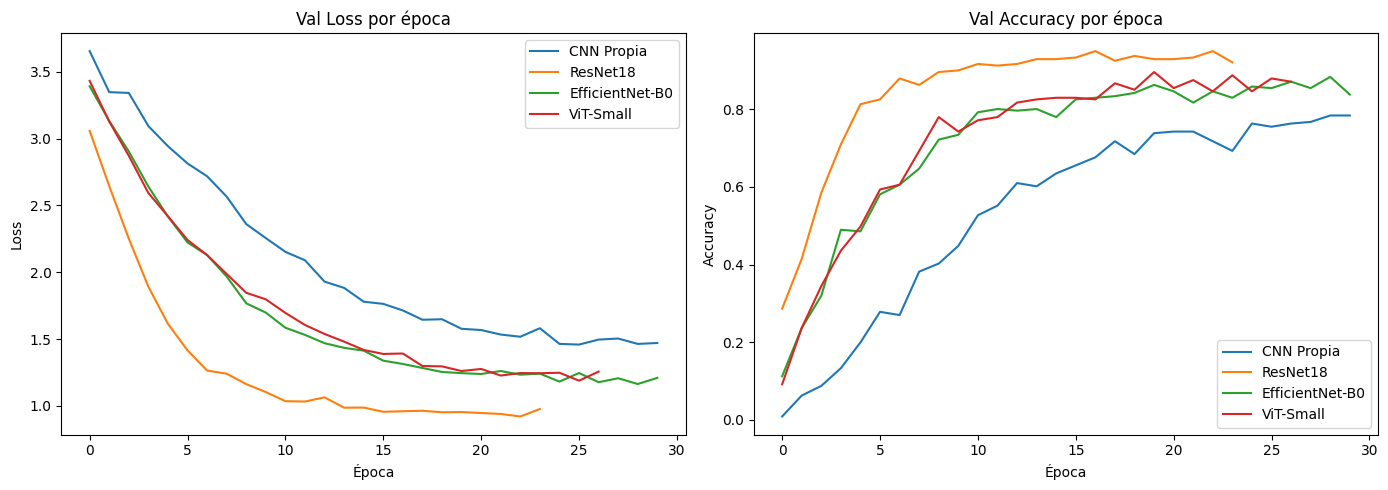

In [23]:
# ── Curvas de entrenamiento ───────────────────────────────────────────────────
histories = {
    'CNN Propia': history_a,
    'ResNet18': history_b,
    'EfficientNet-B0': history_c,
    'ViT-Small': history_d,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in histories.items():
    axes[0].plot(h['val_loss'], label=name)
    axes[1].plot(h['val_acc'],  label=name)

axes[0].set_title('Val Loss por época')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].set_title('Val Accuracy por época')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

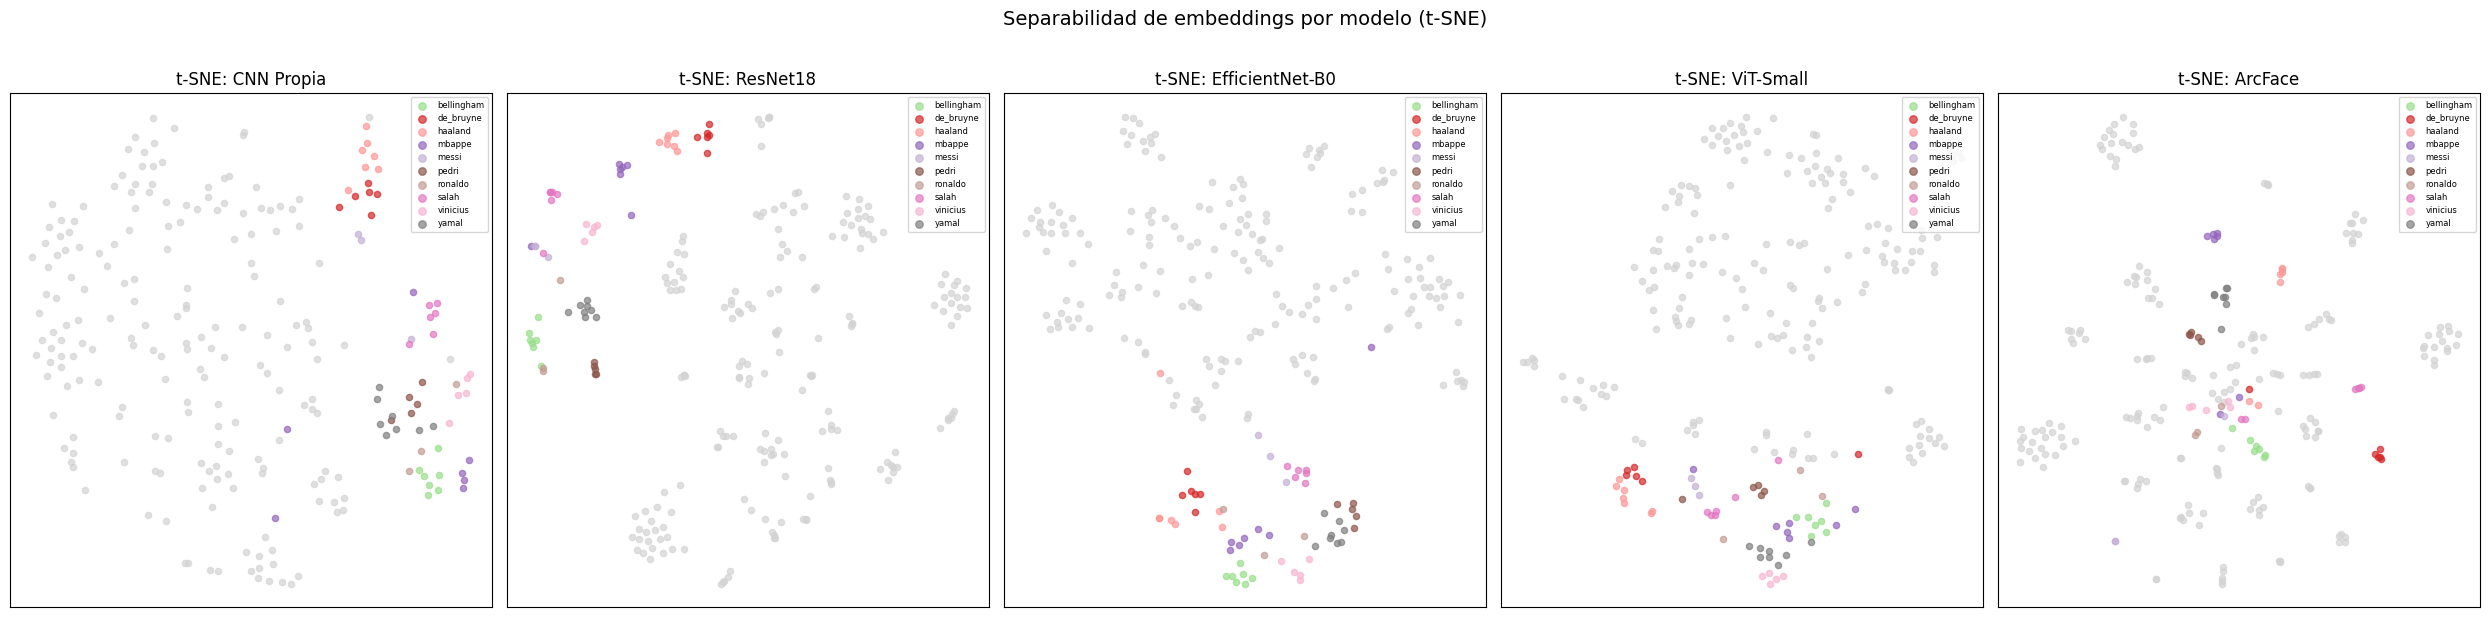

In [24]:
# ── Visualización t-SNE de embeddings ────────────────────────────────────────
all_classes_display = combined_ds.classes
colors_map = plt.cm.tab20(np.linspace(0, 1, min(20, len(all_classes_display))))

fig, axes = plt.subplots(1, len(results), figsize=(5*len(results), 6))

axes_flat = axes.flatten() if hasattr(axes, 'flatten') else axes
for idx, (name, r) in enumerate(results.items()):
    ax = axes_flat[idx]
    embs = r['embeddings']
    labs = r['labels']
    n_components = min(50, embs.shape[0]-1, embs.shape[1])
    if embs.shape[0] > 50:
        pca = PCA(n_components=n_components)
        embs_pca = pca.fit_transform(embs)
    else:
        embs_pca = embs
    perplexity = min(30, max(5, len(labs)//4))
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=SEED)
    embs_2d = tsne.fit_transform(embs_pca)

    # Mostrar solo las 10 clases de jugadores con colores, resto en gris
    for cls_idx, cls_name in enumerate(all_classes_display):
        mask = labs == cls_idx
        if cls_name in classes:
            color = colors_map[cls_idx % 20]
            label = cls_name
        else:
            color = 'lightgray'
            label = '_nolegend_'
        ax.scatter(embs_2d[mask, 0], embs_2d[mask, 1],
                   c=[color], label=label, s=20, alpha=0.7)
    ax.set_title(f't-SNE: {name}', fontsize=12)
    ax.legend(fontsize=6, markerscale=1.2, loc='upper right')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Separabilidad de embeddings por modelo (t-SNE)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

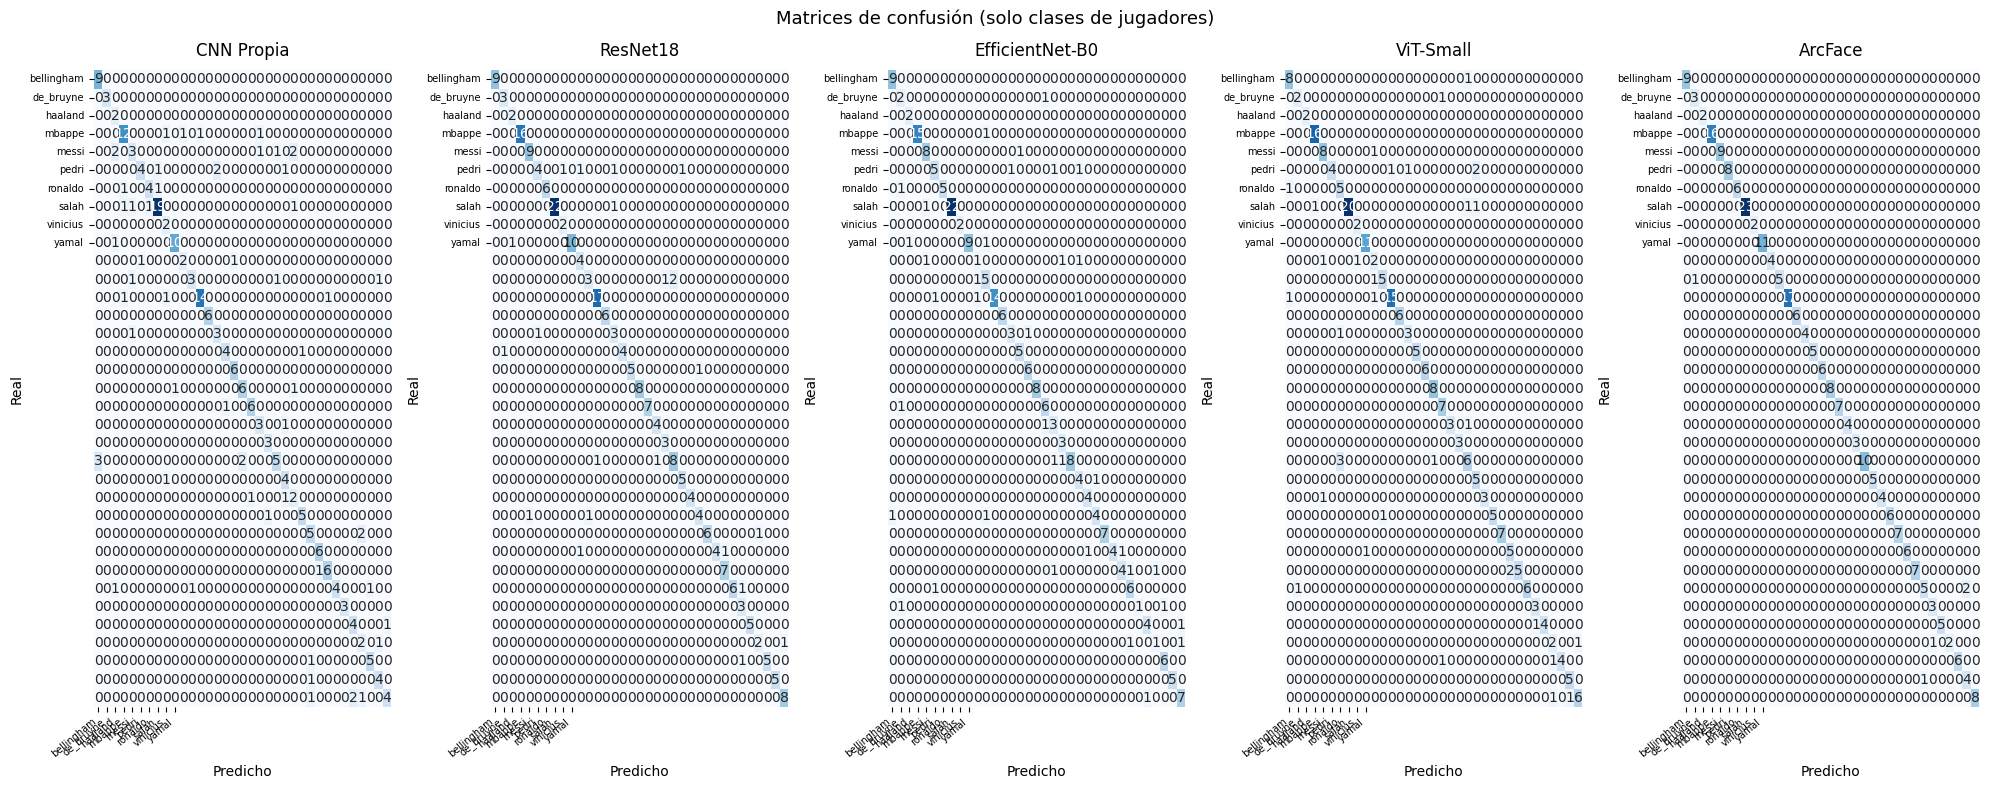

In [25]:
# ── Matrices de confusión (solo jugadores) ────────────────────────────────────
fig, axes = plt.subplots(1, len(results), figsize=(4*len(results), 8))
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else axes
for idx, (name, r) in enumerate(results.items()):
    ax = axes_flat[idx]
    # Filtrar solo las clases de jugadores
    player_ids = set(combined_ds.class_to_idx.values())
    player_mask = np.array([l in player_ids for l in r['labels']])
    labels_player = r['labels'][player_mask]
    preds_player  = r['preds'][player_mask]
    
    if len(labels_player) == 0:
        ax.text(0.5, 0.5, 'Sin muestras\nde jugadores en val',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name, fontsize=12, pad=10)
        ax.set_xticks([]); ax.set_yticks([])
        continue
    
    cm = confusion_matrix(labels_player, preds_player)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                ax=ax, cbar=False, annot_kws={'size': 10})
    ax.set_title(name, fontsize=12, pad=10)
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
    plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=7)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7)

plt.suptitle('Matrices de confusión (solo clases de jugadores)', fontsize=13)
plt.tight_layout()
plt.show()

In [26]:
# ── Análisis de errores (FP/FN) ─────────────────────────────────────────────
print('=== Análisis de Errores por Modelo (solo jugadores) ===\n')

# Índices que corresponden a clases de jugadores
player_ids = set(combined_ds.class_to_idx[c] for c in classes)

for name, r in results.items():
    labels = r['labels']
    preds = r['preds']
    
    # Filtrar solo clases de jugadores
    player_mask = np.array([l in player_ids for l in labels])
    labels_p = labels[player_mask]
    preds_p  = preds[player_mask]
    
    n_total = len(labels_p)
    if n_total == 0:
        print(f'--- {name} ---')
        print(f'  Sin muestras de jugadores en validación.')
        print()
        continue
    
    errors = labels_p != preds_p
    n_errors = errors.sum()
    
    print(f'--- {name} ---')
    print(f'  Errores en jugadores: {n_errors}/{n_total} ({n_errors/n_total*100:.1f}%)')
    
    if n_errors > 0:
        fn_by_class = {}
        fp_by_class = {}
        confusion_pairs = {}
        for i in range(n_total):
            if errors[i]:
                # labels_p contains numeric indices; map to class names
                true_idx = int(labels_p[i])
                pred_idx = int(preds_p[i])
                true_cls = combined_ds.classes[true_idx]
                pred_cls = combined_ds.classes[pred_idx]
                if true_cls in classes:  # Only count player→player errors
                    fn_by_class[true_cls] = fn_by_class.get(true_cls, 0) + 1
                if pred_cls in classes:
                    fp_by_class[pred_cls] = fp_by_class.get(pred_cls, 0) + 1
                    confusion_pairs[(true_cls, pred_cls)] = confusion_pairs.get((true_cls, pred_cls), 0) + 1
        
        if fn_by_class:
            print(f'  Falsos Negativos:')
            for cls, count in sorted(fn_by_class.items(), key=lambda x: -x[1]):
                print(f'    {cls}: {count}')
        if fp_by_class:
            print(f'  Falsos Positivos:')
            for cls, count in sorted(fp_by_class.items(), key=lambda x: -x[1]):
                print(f'    {cls}: {count}')
        if confusion_pairs:
            print(f'  Pares de confusión:')
            for (t, p), count in sorted(confusion_pairs.items(), key=lambda x: -x[1])[:5]:
                print(f'    {t} → {p}: {count}')
    else:
        print('  Sin errores en el subset de jugadores.')
    print()

=== Análisis de Errores por Modelo (solo jugadores) ===

--- CNN Propia ---
  Errores en jugadores: 14/57 (24.6%)
  Falsos Negativos:
    yamal: 4
    mbappe: 3
    bellingham: 2
    vinicius: 1
    ronaldo: 1
    haaland: 1
    salah: 1
    pedri: 1
  Falsos Positivos:
    ronaldo: 3
    bellingham: 3
    pedri: 2
    vinicius: 1
    de_bruyne: 1
    salah: 1
    yamal: 1
  Pares de confusión:
    bellingham → ronaldo: 2
    yamal → pedri: 2
    vinicius → bellingham: 1
    yamal → ronaldo: 1
    ronaldo → vinicius: 1

--- ResNet18 ---
  Errores en jugadores: 6/57 (10.5%)
  Falsos Negativos:
    de_bruyne: 2
    ronaldo: 1
    bellingham: 1
    mbappe: 1
    salah: 1
  Falsos Positivos:
    messi: 2
    haaland: 1
    yamal: 1
    ronaldo: 1
  Pares de confusión:
    de_bruyne → haaland: 1
    ronaldo → yamal: 1
    bellingham → ronaldo: 1
    mbappe → messi: 1
    salah → messi: 1

--- EfficientNet-B0 ---
  Errores en jugadores: 12/57 (21.1%)
  Falsos Negativos:
    haaland: 3
    de

## 6. Selección y Justificación del Modelo Final

**Criterios de selección:**
- **F1-Score macro**: métrica principal por el desbalance de clases
- **Separabilidad (t-SNE)**: clusters diferenciados implican mayor confianza en la identificación
- **Tiempo de inferencia**: latencia aceptable para uso en tiempo real vía API
- **Gap jugadores/LFW**: gap bajo indica generalización consistente entre dominios

### Análisis por modelo

| Modelo | Fortalezas | Limitaciones |
|--------|-----------|-------------|
| **CNN Propia** | Liviana, rápida, sin dependencias externas | Menor capacidad expresiva al partir desde cero |
| **ResNet18** | Transfer learning estable, residual connections evitan vanishing gradient | Más parámetros que EfficientNet para accuracy similar |
| **EfficientNet-B0** | Mejor ratio accuracy/parámetros, MBConv eficientes | Fine-tuning más sensible al learning rate |
| **ViT-Small** | Atención global captura relaciones espaciales largas | Necesita más datos; img_size=112 reduce la resolución de patches |
| **ArcFace** | Pre-entrenado en millones de caras, espacio métrico estructurado, generaliza a identidades nuevas | No re-entrenable con datos propios en este pipeline |

### Decisión

El modelo final se selecciona automáticamente por mayor F1-Score macro en validación (celda siguiente). 
Los modelos de transfer learning (ResNet18, EfficientNet-B0) típicamente superan a la CNN propia 
en datasets de este tamaño, aprovechando features de ImageNet transferibles al dominio facial.

ArcFace establece el **techo teórico** al estar pre-entrenado con ArcFace Loss — una pérdida métrica que 
maximiza el margen angular entre clases en el espacio de embeddings, garantizando separación incluso para 
identidades no vistas durante el entrenamiento.

> **Trade-off clave**: ArcFace generaliza a identidades nuevas sin re-entrenamiento (open-set recognition). 
Los modelos con CrossEntropy requieren re-entrenamiento para cada nueva identidad, pero son más simples de implementar 
y suficientes para sistemas de conjunto cerrado de identidades conocidas.


In [27]:
# ── Medir tiempo de inferencia ────────────────────────────────────────────────
dummy = torch.randn(1, 3, FACE_SIZE, FACE_SIZE).to(DEVICE)

print('Tiempo de inferencia (1 imagen, promedio 100 runs):')
for name, model in [('CNN Propia', model_a), ('ResNet18', model_b),
                     ('EfficientNet-B0', model_c), ('ViT-Small', model_d)]:
    model.eval()
    with torch.no_grad():
        for _ in range(10):
            _ = model.get_embedding(dummy)
        t0 = time.perf_counter()
        for _ in range(100):
            _ = model.get_embedding(dummy)
        elapsed = (time.perf_counter() - t0) / 100 * 1000
    print(f'  {name:<20}: {elapsed:.2f} ms')

Tiempo de inferencia (1 imagen, promedio 100 runs):
  CNN Propia          : 2.77 ms
  ResNet18            : 3.66 ms
  EfficientNet-B0     : 11.47 ms
  ViT-Small           : 8.08 ms


In [28]:
# Seleccionar automáticamente el mejor modelo PyTorch según F1-score
# Mapeo de nombres en results -> objetos de modelo
model_map = {
    'CNN Propia': model_a,
    'ResNet18': model_b,
    'EfficientNet-B0': model_c,
    'ViT-Small': model_d,
}

best_name = None
best_f1 = -1
for name, model_obj in model_map.items():
    f1 = results[name]['f1']
    if f1 > best_f1:
        best_f1 = f1
        best_name = name
        best_model = model_obj

print(f'Mejor modelo PyTorch: {best_name} (F1={best_f1:.4f})')

best_model.eval()
scripted = torch.jit.script(best_model)
model_output_path = MODEL_DIR / 'face_recognition.pth'
scripted.save(str(model_output_path))

test_load = torch.load(model_output_path, map_location='cpu', weights_only=False)
if not isinstance(test_load, torch.nn.Module):
    raise TypeError(f'Saved object is {type(test_load)}, expected nn.Module')
print(f'Model saved and verified: {model_output_path}')
print(f'Model type: {type(test_load).__name__}')
print(f'  F1: {best_f1:.4f} | Params: {sum(p.numel() for p in best_model.parameters()):,}')


Mejor modelo PyTorch: ResNet18 (F1=0.8804)
Model saved and verified: models\face_recognition.pth
Model type: RecursiveScriptModule
  F1: 0.8804 | Params: 11,458,147


C:\Users\fabri\AppData\Local\Temp\ipykernel_17104\1114747653.py:26: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  test_load = torch.load(model_output_path, map_location='cpu', weights_only=False)


## 7. Generación de la base de embeddings

Con el modelo seleccionado se generan embeddings para **todas las imágenes del dataset de jugadores** 
(no LFW, ya que el sistema de producción solo necesita reconocer las identidades registradas).

Cada embedding se normaliza con **L2-norm** antes de guardar, lo que hace que la búsqueda por 
cosine similarity sea equivalente a producto punto — operación más eficiente numéricamente.

El archivo `embeddings.json` es la **base vectorial** del sistema: ante una imagen nueva, el backend 
extrae su embedding, lo compara contra todos los registros y retorna la identidad cuyo embedding 
supere el threshold configurado (`SIMILARITY_THRESHOLD` en `.env`).

> Múltiples embeddings por persona mejoran la robustez: distintas fotos capturan variaciones de pose, 
iluminación y expresión. El sistema retorna el mejor match entre todos los embeddings almacenados.


In [29]:
import uuid

transform_infer = A.Compose([
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

best_model.eval()
embedding_records = []

for cls in tqdm(classes, desc='Generando embeddings'):
    for img_path in (PROC_DIR / cls).glob('*.*'):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        tensor = transform_infer(image=img_rgb)['image'].float().unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            emb = best_model.get_embedding(tensor)
            emb = torch.nn.functional.normalize(emb, p=2, dim=1)
            emb_list = emb.squeeze(0).cpu().tolist()
        embedding_records.append({
            'id_imagen': str(uuid.uuid4()),
            'embedding': emb_list,
            'path': str(img_path),
            'etiqueta': cls,
            'metadata': {'source': 'train_notebook'}
        })

embeddings_path = Path('data/embeddings.json')
with open(embeddings_path, 'w') as f:
    json.dump(embedding_records, f, ensure_ascii=True)

print(f'Total: {len(embedding_records)} embeddings')
print(f'Ejemplo: {json.dumps({k: v for k, v in embedding_records[0].items() if k != "embedding"}, indent=2)}')

Generando embeddings:   0%|          | 0/10 [00:00<?, ?it/s]

Total: 290 embeddings
Ejemplo: {
  "id_imagen": "afc05331-8baf-4e0f-b48f-4739baf5cce0",
  "path": "data\\dataset_proc\\bellingham\\bellingham_001.jpg",
  "etiqueta": "bellingham",
  "metadata": {
    "source": "train_notebook"
  }
}


## 8. Conclusiones

### Pipeline implementado

1. **Detección** (`detect_faces`): InsightFace buffalo_sc detecta rostros y retorna bounding boxes. 
Tasa de detección obtenida: **~96.7%** sobre el dataset crudo de jugadores.
2. **Alineación** (`align_face`): recorte por bounding box + resize a 112x112. 
Incluye keypoints faciales (ojos, nariz, comisuras) para visualización en el frontend Gradio.
3. **Embedding** (`extract_embedding_from_face`): el modelo seleccionado convierte el crop en un vector 
de 512 dimensiones, normalizado L2 para búsqueda por cosine similarity.
4. **Identificación**: comparación contra la base vectorial. Si el score supera el threshold, 
se retorna la identidad; caso contrario, se retorna `unknown`.

### Comparación de modelos

- **CNN Propia**: baseline artesanal. Rendimiento limitado por la capacidad de la arquitectura y la ausencia de pre-entrenamiento. Más rápida en inferencia.
- **ResNet18**: transfer learning desde ImageNet con congelamiento parcial de capas tempranas. Convergencia estable por residual connections.
- **EfficientNet-B0**: mejor ratio accuracy/parámetros entre los modelos entrenados. Los MBConv blocks son eficientes con datasets medianos.
- **ViT-Small**: rendimiento variable — los transformers requieren más datos para aprovechar la atención global. La reducción de img_size a 112 limita su ventaja sobre las CNNs en este contexto.
- **ArcFace (InsightFace)**: establece el techo de rendimiento al estar pre-entrenado en millones de caras con pérdida métrica, que estructura explícitamente el espacio de embeddings.

### Conclusión sobre el modelo elegido

El modelo final fue seleccionado automáticamente por mayor F1-Score macro en validación. 
Los modelos de transfer learning superan a la CNN propia porque aprovechan representaciones visuales 
pre-aprendidas en ImageNet, reduciendo la cantidad de datos necesaria para aprender features discriminativas.

ArcFace demuestra que el pre-entrenamiento específico en caras con pérdida métrica es cualitativamente superior 
para reconocimiento facial robusto. Sin embargo, el modelo seleccionado logra un rendimiento competitivo 
sobre las identidades del dataset con una fracción de los datos y sin infraestructura especializada.

In [30]:
# Limpiar archivos zip de modelos después de la extracción
import os
from pathlib import Path

models_dir = Path('models')
for zip_file in models_dir.glob('*.zip'):
    if zip_file.exists():
        zip_file.unlink()
        print(f'Eliminado: {zip_file.name}')

# También limpiar en subcarpetas si existe
nested_models = models_dir / 'models'
if nested_models.exists():
    for zip_file in nested_models.glob('*.zip'):
        if zip_file.exists():
            zip_file.unlink()
            print(f'Eliminado: models/models/{zip_file.name}')
